In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/kaggle/input/classifier/ecg_resnet18.pth"

# Load checkpoint
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

NUM_CLASSES = ckpt["num_classes"]
LABEL_MAP = ckpt["label_map"]

# Reverse label map for readable output
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# Build model
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(ckpt["model_state"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully")
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [2]:
#Preprocess code for 0
import cv2
import numpy as np
from pathlib import Path


class ScreenContentCropper:
    
    def __init__(self, content_threshold=80, min_area_ratio=0.1):
        self.content_threshold = content_threshold
        self.min_area_ratio = min_area_ratio
    
    def detect_screen_content(self, image, debug=False):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        h, w = gray.shape
        
        if debug:
            print(f"Original size: {w}x{h}")
            cv2.imwrite("debug_01_grayscale.png", gray)
        
        # Method 1: Simple threshold for bright screen content
        _, binary = cv2.threshold(gray, self.content_threshold, 255, cv2.THRESH_BINARY)
        
        if debug:
            cv2.imwrite("debug_02_threshold.png", binary)
        
        # Clean up noise
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=3)
        
        if debug:
            cv2.imwrite("debug_03_cleaned.png", cleaned)
        
        # Find contours
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            print("⚠ No bright content found")
            return None
        
        # Get largest bright region (the screen)
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        
        # Validate size
        area_ratio = (w * h) / (image.shape[0] * image.shape[1])
        if area_ratio < self.min_area_ratio:
            print(f"⚠ Detected area too small ({area_ratio:.2%})")
            return None
        
        if debug:
            print(f"Screen content detected: x={x}, y={y}, w={w}, h={h}")
            print(f"Area ratio: {area_ratio:.2%}")
        
        return (x, y, w, h)
    
    def detect_screen_adaptive(self, image, debug=False):
        """
        Alternative method using adaptive thresholding
        Better for screens with varying brightness
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Adaptive threshold
        binary = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 51, -10
        )
        
        if debug:
            cv2.imwrite("debug_04_adaptive.png", binary)
        
        # Clean and fill
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
        cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=5)
        
        if debug:
            cv2.imwrite("debug_05_adaptive_cleaned.png", cleaned)
        
        # Find largest region
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            return None
        
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        
        if debug:
            print(f"Adaptive method: x={x}, y={y}, w={w}, h={h}")
        
        return (x, y, w, h)
    
    def detect_screen_edges(self, image, debug=False):
        """
        Method using edge detection to find screen boundary
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Canny edge detection
        edges = cv2.Canny(blurred, 30, 100)
        
        if debug:
            cv2.imwrite("debug_06_edges.png", edges)
        
        # Dilate to connect screen edges
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        dilated = cv2.dilate(edges, kernel, iterations=3)
        
        # Fill holes
        dilated = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel, iterations=5)
        
        if debug:
            cv2.imwrite("debug_07_edges_processed.png", dilated)
        
        # Find largest region
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            return None
        
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        
        if debug:
            print(f"Edge method: x={x}, y={y}, w={w}, h={h}")
        
        return (x, y, w, h)
    
    def smart_crop(self, image, method='auto', debug=False):
        """
        Detect and crop to screen content only
        
        Args:
            image: Input image
            method: 'simple', 'adaptive', 'edges', or 'auto'
            debug: Enable debug output
        """
        print("="*60)
        print("SCREEN CONTENT DETECTION & CROP")
        print("="*60)
        print(f"Input size: {image.shape[1]}x{image.shape[0]}")
        print(f"Method: {method}")
        print(f"Content threshold: {self.content_threshold}")
        
        roi = None
        
        if method == 'simple':
            if debug:
                print("\n[Simple threshold method]")
            roi = self.detect_screen_content(image, debug=debug)
        
        elif method == 'adaptive':
            if debug:
                print("\n[Adaptive threshold method]")
            roi = self.detect_screen_adaptive(image, debug=debug)
        
        elif method == 'edges':
            if debug:
                print("\n[Edge detection method]")
            roi = self.detect_screen_edges(image, debug=debug)
        
        elif method == 'auto':
            print("\n[AUTO] Trying all methods...")
            
            methods = [
                ('Simple', lambda: self.detect_screen_content(image, debug=False)),
                ('Adaptive', lambda: self.detect_screen_adaptive(image, debug=False)),
                ('Edges', lambda: self.detect_screen_edges(image, debug=False))
            ]
            
            best_roi = None
            best_score = 0
            
            for name, method_func in methods:
                print(f"  Trying {name}...", end=" ")
                try:
                    test_roi = method_func()
                    if test_roi is not None:
                        x, y, w, h = test_roi
                        area = w * h
                        orig_area = image.shape[0] * image.shape[1]
                        area_ratio = area / orig_area
                        
                        # Score based on area ratio (want significant but not full image)
                        # Ideal range: 20-80% of original
                        if 0.15 < area_ratio < 0.90:
                            # Prefer rectangular shapes (screens are rectangular)
                            aspect_ratio = w / h if h > 0 else 0
                            aspect_score = 1.0 if 1.2 < aspect_ratio < 2.0 else 0.5
                            
                            score = area_ratio * aspect_score
                            
                            print(f"✓ ({w}x{h}, {area_ratio:.1%}, score={score:.3f})")
                            
                            if score > best_score:
                                best_roi = test_roi
                                best_score = score
                        else:
                            print(f"✗ (invalid size: {area_ratio:.1%})")
                    else:
                        print("✗ (no detection)")
                except Exception as e:
                    print(f"✗ ({e})")
            
            roi = best_roi
            
            if debug and roi is not None:
                vis = image.copy()
                x, y, w, h = roi
                cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 5)
                cv2.imwrite("debug_08_final_detection.png", vis)
        
        else:
            raise ValueError(f"Unknown method: {method}")
        
        # Crop
        if roi is None:
            print("\n✗ Could not detect screen content")
            print("  Try adjusting content_threshold (currently {})".format(self.content_threshold))
            print("="*60)
            return image
        
        x, y, w, h = roi
        
        # Add small padding to ensure we don't cut content (optional)
        padding = 5
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(image.shape[1] - x, w + 2*padding)
        h = min(image.shape[0] - y, h + 2*padding)
        
        cropped = image[y:y+h, x:x+w]
        
        # Stats
        orig_h, orig_w = image.shape[:2]
        removed = (orig_w * orig_h) - (w * h)
        removed_pct = 100 * removed / (orig_w * orig_h)
        
        print(f"\n✓ Success!")
        print(f"  Original: {orig_w}x{orig_h}")
        print(f"  Cropped:  {w}x{h}")
        print(f"  Removed:  {removed:,} pixels ({removed_pct:.1f}%)")
        print(f"  Kept:     {100-removed_pct:.1f}% (screen content only)")
        print("="*60)
        
        if debug:
            # Show comparison
            vis = image.copy()
            cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 5)
            cv2.imwrite("debug_09_crop_area.png", vis)
        
        return cropped
    
    def batch_process(self, input_folder, output_folder, method='auto'):
        """Process multiple images"""
        input_path = Path(input_folder)
        output_path = Path(output_folder)
        output_path.mkdir(parents=True, exist_ok=True)
        
        extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
        files = []
        for ext in extensions:
            files.extend(input_path.glob(f'*{ext}'))
            files.extend(input_path.glob(f'*{ext.upper()}'))
        
        print(f"Found {len(files)} images\n")
        
        success = 0
        for i, f in enumerate(files, 1):
            print(f"[{i}/{len(files)}] {f.name}")
            try:
                img = cv2.imread(str(f))
                if img is None:
                    print("  ✗ Cannot read")
                    continue
                
                cropped = self.smart_crop(img, method=method, debug=False)
                
                out = output_path / f"cropped_{f.name}"
                cv2.imwrite(str(out), cropped)
                success += 1
                print(f"  ✓ Saved to {out.name}\n")
            except Exception as e:
                print(f"  ✗ Error: {e}\n")
        
        print(f"\n{'='*60}")
        print(f"Completed: {success}/{len(files)} images")
        print(f"Output folder: {output_path}")

import cv2
import glob
import numpy as np
import os
from helper import * 

import sys, importlib.util

# Load ECG utils as ecg_utils
ecg_path = "/kaggle/input/ecg-utils/utils.py"
spec = importlib.util.spec_from_file_location("ecg_utils", ecg_path)
ecg_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ecg_utils)

# Load constants normally
sys.path.insert(0, "/kaggle/input/ecg-utils")
import constant


reduce_glare = ecg_utils.reduce_glare
mix_filter = ecg_utils.mix_filter


def detect_corner_qr_patterns(image, corner_size_percent=0.30):
    
    h, w = image.shape[:2]
    
    # 1. Calculate the size (30% of width/height)
    corner_w = int(w * corner_size_percent)
    corner_h = int(h * corner_size_percent)
    
    # 2. Calculate coordinates for Top-Right
    # x start = total width - corner width
    x = w - corner_w
    y = 0
    
    # 3. Return the region unconditionally
    # Format: [(x, y, width, height)]
    return [(x, y, corner_w, corner_h)]

def create_protection_mask(image_shape, qr_regions):

    mask = np.ones(image_shape[:2], dtype=np.uint8) * 255
    
    for (x, y, w, h) in qr_regions:
        # Mark QR region as protected (0 = don't process)
        cv2.rectangle(mask, (x, y), (x + w, y + h), 0, -1)
    
    return mask


def apply_glare_reduction_with_protection(image, qr_regions, method='RG'):

    # Create protection mask
    protection_mask = create_protection_mask(image.shape, qr_regions)
    
    # Apply the glare reduction method
    if method == 'RG':
        processed = reduce_glare(image)
    elif method == 'RG+EC':
        processed = mix_filter(image)
    else:
        processed = image.copy()
    
    # Blend: Keep original in QR regions, use processed elsewhere
    # Where mask is 0 (QR region), use original; where 255, use processed
    result = np.where(protection_mask[:, :, None] == 0, image, processed)
    
    return result.astype(np.uint8)

import cv2
import os

def preprocess_single_image(image, use_mix=True):
    """
    image_path : str -> path to input image
    use_mix    : bool -> True = RG + EC, False = RG only

    returns: final preprocessed image (numpy array)
    """

    # Load image
    image = image
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Detect QR codes / corner patterns
    qr_regions = detect_corner_qr_patterns(image)

    # Apply pipeline
    if use_mix:   # RG + EC
        if qr_regions:
            final_img = apply_glare_reduction_with_protection(
                image, qr_regions, method='RG+EC'
            )
        else:
            final_img = mix_filter(image)
    else:         # RG only
        if qr_regions:
            final_img = apply_glare_reduction_with_protection(
                image, qr_regions, method='RG'
            )
        else:
            final_img = reduce_glare(image)

    return final_img



import cv2
import numpy as np
from pathlib import Path

class ECGDistortionCorrector:
    def __init__(self, resize_width=1200, resize_height=900):
        """
        Initialize ECG Distortion Corrector
        
        Args:
            resize_width: Width to resize image for processing
            resize_height: Height to resize image for processing
        """
        self.resize_width = resize_width
        self.resize_height = resize_height
    
    def preprocess_image(self, image):
        """Resize and apply Gaussian filter to reduce noise"""
        resized = cv2.resize(image, (self.resize_width, self.resize_height))
        blurred = cv2.GaussianBlur(resized, (5, 5), 0)
        return blurred
    
    def find_paper_corners_robust(self, image, debug=False):
        """
        Robust method to find the 4 corners of ECG paper
        Handles wrinkled paper and irregular edges
        """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Apply bilateral filter to reduce noise while keeping edges
        filtered = cv2.bilateralFilter(gray, 9, 75, 75)
        
        # Use Otsu's thresholding
        _, binary = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Invert if paper is darker than background
        if np.mean(binary[binary > 0]) < 127:
            binary = cv2.bitwise_not(binary)
        
        if debug:
            cv2.imwrite("debug_binary.png", binary)
        
        # Morphological operations to clean up
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
        
        if debug:
            cv2.imwrite("debug_binary_cleaned.png", binary)
        
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            return None
        
        # Find the largest contour (should be the paper)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Get the convex hull (helps with wrinkled edges)
        hull = cv2.convexHull(largest_contour)
        
        # Approximate to polygon with fewer points
        epsilon = 0.01 * cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, epsilon, True)
        
        if debug:
            print(f"Initial approximation: {len(approx)} points")
            debug_img = image.copy()
            cv2.drawContours(debug_img, [approx], -1, (0, 255, 0), 3)
            for i, pt in enumerate(approx):
                cv2.circle(debug_img, tuple(pt[0]), 10, (255, 0, 0), -1)
                cv2.putText(debug_img, str(i), tuple(pt[0]), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            cv2.imwrite("debug_initial_approx.png", debug_img)
        
        # If we have more than 4 points, find the 4 extreme corners

        if len(approx) >= 4:                                  ###################SAHAJ
            points = approx.reshape(-1, 2)
            corners = self.find_four_corners_from_points(points)
            
            if debug:
                print(f"Selected 4 corners from {len(points)} points")
                debug_img = image.copy()
                for i, pt in enumerate(corners):
                    cv2.circle(debug_img, tuple(pt.astype(int)), 15, (0, 255, 0), -1)
                    cv2.putText(debug_img, str(i), tuple(pt.astype(int)), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                cv2.imwrite("debug_final_corners.png", debug_img)
            
            return corners
        
        return None
    
    def find_four_corners_from_points(self, points):
        """
        Find the 4 extreme corner points from a set of points
        Returns: [top-left, top-right, bottom-left, bottom-right]
        """
        # Find extreme points
        top_left = points[np.argmin(points[:, 0] + points[:, 1])]
        top_right = points[np.argmax(points[:, 0] - points[:, 1])]
        bottom_left = points[np.argmax(points[:, 1] - points[:, 0])]
        bottom_right = points[np.argmax(points[:, 0] + points[:, 1])]
        
        corners = np.array([top_left, top_right, bottom_left, bottom_right], dtype=np.float32)
        
        return corners
    
    def order_points(self, pts):
        """
        Order points consistently: top-left, top-right, bottom-left, bottom-right
        """
        # Initialize ordered points
        rect = np.zeros((4, 2), dtype=np.float32)
        
        # Sum and difference
        s = pts.sum(axis=1)
        diff = np.diff(pts, axis=1)
        
        # Top-left has smallest sum
        rect[0] = pts[np.argmin(s)]
        # Bottom-right has largest sum
        rect[3] = pts[np.argmax(s)]
        # Top-right has smallest difference
        rect[1] = pts[np.argmin(diff)]
        # Bottom-left has largest difference
        rect[2] = pts[np.argmax(diff)]
        
        return rect
    
    def apply_perspective_transform(self, image, corners):
        """Apply perspective transformation to correct distortion"""
        # Order the corners
        corners = self.order_points(corners)
        
        # Calculate width and height of corrected image
        width_top = np.linalg.norm(corners[1] - corners[0])
        width_bottom = np.linalg.norm(corners[3] - corners[2])
        max_width = int(max(width_top, width_bottom))
        
        height_left = np.linalg.norm(corners[2] - corners[0])
        height_right = np.linalg.norm(corners[3] - corners[1])
        max_height = int(max(height_left, height_right))
        
        # Destination points (rectangle)
        dst = np.array([
            [0, 0],
            [max_width - 1, 0],
            [0, max_height - 1],
            [max_width - 1, max_height - 1]
        ], dtype=np.float32)
        
        # Calculate perspective transform matrix
        matrix = cv2.getPerspectiveTransform(corners, dst)
        
        # Apply transformation
        warped = cv2.warpPerspective(image, matrix, (max_width, max_height))
        
        return warped
    
    def enhance_contrast(self, image):
        """Enhance image contrast for better processing"""
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        
        # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        
        enhanced = cv2.merge([l, a, b])
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
        
        return enhanced
    
    def correct_distortion(self, image, output_path=None, visualize=False, debug=False):
        """
        Main function to correct ECG image distortion
        
        Args:
            image_path: Path to input ECG image
            output_path: Path to save corrected image (optional)
            visualize: Whether to show intermediate results
            debug: Print debug information and save intermediate images
        
        Returns:
            corrected_image: Distortion-corrected ECG image
        """
        # Read original image
        # original = cv2.imread(str(image_path))
        original = image
        if original is None:
            raise ValueError(f"Could not read image from {image_path}")
        
        original_shape = original.shape
        if debug:
            print(f"Original image shape: {original_shape}")
        
        # Preprocess
        processed = self.preprocess_image(original)
        
        if debug:
            cv2.imwrite("debug_preprocessed.png", processed)
            print("Preprocessed image saved to debug_preprocessed.png")
        
        # Enhance contrast
        enhanced = self.enhance_contrast(processed)
        
        if debug:
            cv2.imwrite("debug_enhanced.png", enhanced)
            print("Enhanced image saved to debug_enhanced.png")
        
        # Find corners
        corners = self.find_paper_corners_robust(enhanced, debug=debug)
        
        if corners is None:
            print("Could not detect corners. Returning original image.")
            return original
        
        # Map corners back to original image coordinates
        h_ratio = original_shape[0] / self.resize_height
        w_ratio = original_shape[1] / self.resize_width
        
        original_corners = corners.copy()
        original_corners[:, 0] *= w_ratio
        original_corners[:, 1] *= h_ratio
        
        if debug:
            print(f"Detected corners (in original coordinates):")
            for i, corner in enumerate(original_corners):
                print(f"  Corner {i}: {corner}")
        
        # Apply perspective transformation
        corrected = self.apply_perspective_transform(original, original_corners)
        
        # Visualize if requested
        if visualize:
            # Draw corners on original
            vis_image = original.copy()
            ordered_corners = self.order_points(original_corners)
            
            corner_labels = ['TL', 'TR', 'BL', 'BR']
            colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
            
            for i, (corner, label, color) in enumerate(zip(ordered_corners, corner_labels, colors)):
                pt = tuple(corner.astype(int))
                cv2.circle(vis_image, pt, 20, color, -1)
                cv2.putText(vis_image, label, (pt[0] - 20, pt[1] - 20), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)
            
            # Draw lines between corners
            for i in range(4):
                pt1 = tuple(ordered_corners[i].astype(int))
                pt2 = tuple(ordered_corners[(i + 1) % 4].astype(int))
                cv2.line(vis_image, pt1, pt2, (0, 255, 255), 3)
            
            # Resize for display if too large
            max_display_width = 1400
            if vis_image.shape[1] > max_display_width:
                scale = max_display_width / vis_image.shape[1]
                vis_image = cv2.resize(vis_image, None, fx=scale, fy=scale)
            
            if corrected.shape[1] > max_display_width:
                scale = max_display_width / corrected.shape[1]
                corrected_display = cv2.resize(corrected, None, fx=scale, fy=scale)
            else:
                corrected_display = corrected
            
            #cv2.imshow('Detected Corners', vis_image)
            #cv2.imshow('Corrected Image', corrected_display)
            print("Press any key to close windows...")
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        
        # Save output if path provided
        if output_path:
            cv2.imwrite(str(output_path), corrected)
            print(f"Corrected image saved to {output_path}")
        
        return corrected
    
    def batch_process(self, input_folder, output_folder, debug=False):
        """
        Process multiple ECG images in a folder
        
        Args:
            input_folder: Path to folder containing ECG images
            output_folder: Path to save corrected images
            debug: Enable debug mode
        """
        input_path = Path(input_folder)
        output_path = Path(output_folder)
        output_path.mkdir(exist_ok=True, parents=True)
        
        # Supported image formats
        image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
        
        image_files = []
        for ext in image_extensions:
            image_files.extend(input_path.glob(f'*{ext}'))
            image_files.extend(input_path.glob(f'*{ext.upper()}'))
        
        print(f"Found {len(image_files)} images to process")
        
        success_count = 0
        for i, img_file in enumerate(image_files, 1):
            print(f"\nProcessing {i}/{len(image_files)}: {img_file.name}")
            
            try:
                output_file = output_path / f"corrected_{img_file.name}"
                corrected = self.correct_distortion(
                    str(img_file),
                    output_path=str(output_file),
                    visualize=False,
                    debug=debug
                )
                
                if corrected is not None:
                    success_count += 1
                    print(f"✓ Successfully processed: {img_file.name}")
                else:
                    print(f"✗ Failed to process: {img_file.name}")
                    
            except Exception as e:
                print(f"✗ Error processing {img_file.name}: {e}")
        
        print(f"\n{'='*50}")
        print(f"Batch processing complete!")
        print(f"Successfully processed: {success_count}/{len(image_files)}")
        print(f"Output folder: {output_path}")


import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def process_ecg_detailed(image):
    # 1. Load Image
    # if not os.path.exists(image_path):
    #     print(f"Error: File {image_path} not found.")
    #     return
    
    img = image
    
    # 2. Convert to Grayscale (Solves mixed colors)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Moire Removal (Bilateral Filter)
    # We use slightly gentler settings here to ensure we don't blur fine details.
    # d=5 looks at a smaller area than before, preserving tighter grid lines.
    cleaned = cv2.bilateralFilter(gray, d=5, sigmaColor=50, sigmaSpace=50)

    # 4. Sharpening (Unsharp Masking)
    # This is the key to "detailed but not thick".
    # We subtract a blurred version from the original to make edges 'pop'.
    gaussian = cv2.GaussianBlur(cleaned, (0, 0), 2.0)
    # Formula: Original + (Original - Blurred) * Amount
    # Amount (1.5) controls how much detail is added.
    sharpened = cv2.addWeighted(cleaned, 1.5, gaussian, -0.5, 0)

    # 5. Gamma Correction
    # This adjusts the lighting linearity. 
    # Gamma < 1.0 (e.g., 0.8) makes faint signals darker without thickening them.
    gamma = 0.8
    look_up_table = np.array([((i / 255.0) ** gamma) * 255 
                              for i in np.arange(0, 256)]).astype("uint8")
    gamma_corrected = cv2.LUT(sharpened, look_up_table)

    # 6. Normalization
    # Stretches the darkest pixel to black and brightest to white to fix "glare".
    final_img = cv2.normalize(gamma_corrected, None, 0, 255, cv2.NORM_MINMAX)

    # Save
    output_path = "/kaggle/working/preprocessed_merged.png"
    cv2.imwrite(output_path, final_img)
    print(f"Detailed image saved to: {output_path}")


In [3]:
def preprocess_0(image_path):
    cropper = ScreenContentCropper(
        content_threshold=80,    # Brightness threshold (0-255)
        min_area_ratio=0.1       # Minimum 10% of image
    )
    
    # Single image with debug visualization
    image = cv2.imread(image_path)
    if image is not None:
        cropped = cropper.smart_crop(image, method='auto', debug=True)
        #cv2.imwrite(r"/kaggle/working/mycrop.png", cropped)
        print("\n Cropped")
    
    pre = preprocess_single_image(cropped)
    corrector = ECGDistortionCorrector()
    corrected = corrector.correct_distortion(pre)
    #filename = str(image_path.split("/")[-1])

    
    a = process_ecg_detailed(corrected)
    return a

In [4]:
import cv2
import numpy as np
from pathlib import Path


def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)
        pred = out.argmax(1).item()

    return pred

In [5]:
def preprocess(pred_class, img_path):
    if (pred_class == 0):
        
        preprocess_0(img_path)
    
    elif(pred_class==1):
        import cv2
        import numpy as np
        from pathlib import Path
        
        
        class ECGPreprocessor:
            def __init__(self, target_height=900):
                """
                Initialize ECG Preprocessor with comprehensive artifact handling
                
                Args:
                    target_height: Height to resize final image
                    target_dpi: Target DPI for resolution standardization
                """
                self.target_height = target_height
                # self.target_dpi = target_dpi
            
            # ==================== DISTORTION CORRECTION (KEPT AS-IS) ====================
            
            def detect_paper_edges(self, image, debug=False):
                """
                Detect the 4 corners of ECG paper
                
                Returns:
                    corners: Array of 4 corner points [top-left, top-right, bottom-left, bottom-right]
                """
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Bilateral filter to reduce noise while keeping edges
                filtered = cv2.bilateralFilter(gray, 9, 75, 75)
                
                # Otsu's thresholding
                _, binary = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                
                # Invert if paper is darker than background
                if np.mean(binary[binary > 0]) < 127:
                    binary = cv2.bitwise_not(binary)
                
                # Morphological operations to clean up
                kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
                binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
                binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
                
                # Find contours
                contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                if len(contours) == 0:
                    return None
                
                # Find largest contour (the paper)
                largest_contour = max(contours, key=cv2.contourArea)
                
                # Get convex hull
                hull = cv2.convexHull(largest_contour)
                
                # Approximate to polygon
                epsilon = 0.01 * cv2.arcLength(hull, True)
                approx = cv2.approxPolyDP(hull, epsilon, True)
                
                # Find the 4 extreme corners
                if len(approx) >= 4:
                    points = approx.reshape(-1, 2)
                    corners = self._find_four_corners(points)
                    
                    if debug:
                        print(f"Detected paper corners at: {corners}")
                    
                    return corners
                
                return None
            
            def _find_four_corners(self, points):
                """
                Find 4 extreme corner points from a set of points
                Returns: [top-left, top-right, bottom-left, bottom-right]
                """
                top_left = points[np.argmin(points[:, 0] + points[:, 1])]
                top_right = points[np.argmax(points[:, 0] - points[:, 1])]
                bottom_left = points[np.argmax(points[:, 1] - points[:, 0])]
                bottom_right = points[np.argmax(points[:, 0] + points[:, 1])]
                
                return np.array([top_left, top_right, bottom_left, bottom_right], dtype=np.float32)
            
            def _order_points(self, pts):
                """Order points: top-left, top-right, bottom-left, bottom-right"""
                rect = np.zeros((4, 2), dtype=np.float32)
                
                s = pts.sum(axis=1)
                diff = np.diff(pts, axis=1)
                
                rect[0] = pts[np.argmin(s)]      # top-left
                rect[3] = pts[np.argmax(s)]      # bottom-right
                rect[1] = pts[np.argmin(diff)]   # top-right
                rect[2] = pts[np.argmax(diff)]   # bottom-left
                
                return rect
            
            def perspective_transform(self, image, corners, debug=False):
                """Apply perspective transformation and crop tightly to paper"""
                corners = self._order_points(corners)
                
                # Calculate dimensions
                width_top = np.linalg.norm(corners[1] - corners[0])
                width_bottom = np.linalg.norm(corners[3] - corners[2])
                max_width = int(max(width_top, width_bottom))
                
                height_left = np.linalg.norm(corners[2] - corners[0])
                height_right = np.linalg.norm(corners[3] - corners[1])
                max_height = int(max(height_left, height_right))
                
                # Destination points (rectangle)
                dst = np.array([
                    [0, 0],
                    [max_width - 1, 0],
                    [0, max_height - 1],
                    [max_width - 1, max_height - 1]
                ], dtype=np.float32)
                
                # Calculate and apply transformation
                matrix = cv2.getPerspectiveTransform(corners, dst)
                warped = cv2.warpPerspective(image, matrix, (max_width, max_height))
                
                # Now aggressively crop the warped image to remove borders
                gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
                
                # Any pixel that's not pure white (< 253) is content
                not_white = gray < 253
                
                # Find the bounding box of all non-white content
                rows = np.any(not_white, axis=1)
                cols = np.any(not_white, axis=0)
                
                if np.any(rows) and np.any(cols):
                    y_min, y_max = np.where(rows)[0][[0, -1]]
                    x_min, x_max = np.where(cols)[0][[0, -1]]
                    
                    # Add 1 to max indices for slicing
                    y_max += 1
                    x_max += 1
                    
                    if debug:
                        print(f"Warped size: {max_width}x{max_height}")
                        print(f"Content bounds: x=[{x_min}:{x_max}], y=[{y_min}:{y_max}]")
                        print(f"Final size: {x_max-x_min}x{y_max-y_min}")
                    
                    # Crop to content
                    warped = warped[y_min:y_max, x_min:x_max]
                
                return warped
            
            def crop_to_content(self, image, debug=False):
                """Aggressively crop to remove ALL white borders"""
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Find rows and columns that have ANY non-white pixels
                # Use a very aggressive threshold - anything below 250 is content
                threshold = 250
                
                # Check each row - if it has any pixel darker than threshold, keep it
                row_has_content = np.any(gray < threshold, axis=1)
                # Check each column
                col_has_content = np.any(gray < threshold, axis=0)
                
                # Find the first and last row/column with content
                rows_with_content = np.where(row_has_content)[0]
                cols_with_content = np.where(col_has_content)[0]
                
                if len(rows_with_content) == 0 or len(cols_with_content) == 0:
                    if debug:
                        print("Warning: No content found, returning original image")
                    return image
                
                y_min = rows_with_content[0]
                y_max = rows_with_content[-1] + 1
                x_min = cols_with_content[0]
                x_max = cols_with_content[-1] + 1
                
                if debug:
                    print(f"Original size: {image.shape[1]}x{image.shape[0]}")
                    print(f"Crop bounds: x=[{x_min}:{x_max}], y=[{y_min}:{y_max}]")
                    print(f"Cropped size: {x_max-x_min}x{y_max-y_min}")
                    print(f"Removed: left={x_min}px, right={image.shape[1]-x_max}px, top={y_min}px, bottom={image.shape[0]-y_max}px")
                
                return image[y_min:y_max, x_min:x_max]
            
            # ==================== CONTRAST ENHANCEMENT (FROM SECOND CODE) ====================
            
            def detect_blur(self, image, debug=False):
                """
                Detect if image is blurry using Laplacian variance
                Returns blur score (lower = more blurry)
                """
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
                
                # Threshold for blur detection (empirical)
                blur_threshold = 100
                is_blurry = laplacian_var < blur_threshold
                
                if debug:
                    print(f"Blur score (Laplacian variance): {laplacian_var:.2f}")
                    print(f"Blurry: {is_blurry} (threshold: {blur_threshold})")
                
                return is_blurry, laplacian_var
            
            def detect_noise(self, image, debug=False):
                """
                Detect if image has significant noise
                Returns True if noise reduction is recommended
                """
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Calculate noise estimate using high-frequency components
                blurred = cv2.GaussianBlur(gray, (5, 5), 0)
                noise = cv2.absdiff(gray, blurred)
                
                # Calculate noise level
                noise_level = np.mean(noise)
                
                # Threshold for noise detection
                noise_threshold = 5.0
                has_noise = noise_level > noise_threshold
                
                if debug:
                    print(f"Noise level: {noise_level:.2f}")
                    print(f"Has significant noise: {has_noise} (threshold: {noise_threshold})")
                
                return has_noise, noise_level
            
            def sharpen_image(self, image, strength=1.5, debug=False):
                """
                Sharpen blurry image using unsharp masking
                """
                # Create Gaussian blur
                blurred = cv2.GaussianBlur(image, (0, 0), 3)
                
                # Unsharp mask: original + (original - blurred) * strength
                sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
                
                if debug:
                    print(f"Applied sharpening with strength {strength}")
                
                return sharpened
            
            def reduce_noise(self, image, strength='light', debug=False):
                """
                Reduce scanning noise and artifacts using Non-Local Means Denoising
                
                Args:
                    strength: 'light' (h=3), 'medium' (h=5), 'strong' (h=10)
                """
                strength_params = {
                    'light': (3, 3),
                    'medium': (5, 5),
                    'strong': (10, 10)
                }
                
                h_luma, h_color = strength_params.get(strength, (3, 3))
                
                denoised = cv2.fastNlMeansDenoisingColored(image, None, h_luma, h_color, 7, 21)
                
                if debug:
                    print(f"Applied {strength} noise reduction (h_luma={h_luma}, h_color={h_color})")
                
                return denoised
            
            def normalize_brightness(self, image, debug=False):
                """
                Normalize brightness for ECG images
                Goal: Keep signal dark, background light, maximize contrast
                """
                # Convert to LAB color space
                lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                
                # Reduced gamma to minimize brightness changes
                gamma = 1.1
                inv_gamma = 1.0 / gamma
                table = np.array([((i / 255.0) ** inv_gamma) * 255 
                                 for i in range(256)]).astype("uint8")
                l = cv2.LUT(l, table)
                
                # Reduced brightness boost
                mask = l > 128
                l[mask] = np.clip(l[mask] * 1.05, 0, 255).astype(np.uint8)
                
                # Merge back
                enhanced = cv2.merge([l, a, b])
                result = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
                
                if debug:
                    print("Applied gentle brightness normalization (gamma=1.1)")
                
                return result
            
            def final_sharpen(self, image, debug=False):
                """
                Apply final sharpening after all transformations
                Uses unsharp masking with optimal parameters for ECG signals
                """
                # Use smaller sigma to preserve fine details
                gaussian = cv2.GaussianBlur(image, (0, 0), 2.0)
                sharpened = cv2.addWeighted(image, 1.5, gaussian, -0.5, 0)
                
                if debug:
                    print("Applied final sharpening (unsharp mask, sigma=2.0)")
                
                return sharpened
            
            def adaptive_threshold(self, image):
                """Apply adaptive thresholding for better contrast"""
                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Adaptive thresholding
                binary = cv2.adaptiveThreshold(
                    gray, 255, 
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                    cv2.THRESH_BINARY, 
                    11, 2
                )
                
                # Convert back to BGR
                return cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
            
            def suppress_grid(self, image, debug=False):
                """Suppress red gridlines (optional)"""
                hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
                h, s, v = cv2.split(hsv)
                
                # Mask for red hues
                mask1 = cv2.inRange(h, 156, 180)
                mask2 = cv2.inRange(h, 0, 10)
                red_mask = cv2.bitwise_or(mask1, mask2)
                
                # Set saturation to 0 for red pixels (makes them white)
                s[red_mask > 0] = 0
                
                # Merge and convert back
                hsv_cleaned = cv2.merge([h, s, v])
                
                if debug:
                    print("Removed red gridlines using HSV masking")
                
                return cv2.cvtColor(hsv_cleaned, cv2.COLOR_HSV2BGR)
            
            def resize_to_height(self, image, height=None):
                """Resize image to target height while maintaining aspect ratio"""
                if height is None:
                    height = self.target_height
                
                h, w = image.shape[:2]
                aspect_ratio = w / h
                new_width = int(height * aspect_ratio)
                
                resized = cv2.resize(image, (new_width, height), interpolation=cv2.INTER_AREA)
                return resized
            
            # ==================== MAIN PREPROCESSING PIPELINE ====================
            
            def preprocess(self, image_path, output_path=None, 
                           fix_blur=True,
                           reduce_noise_flag='auto',
                           apply_threshold=True, 
                           apply_grid_suppression=True,
                           apply_final_sharpening=True,
                           debug=False):
                """
                Complete preprocessing pipeline
                KEEPS: Original distortion correction logic
                ADDS: Contrast enhancement from second code
                
                Args:
                    image_path: Path to input ECG image
                    output_path: Path to save output (optional)
                    fix_blur: Detect and sharpen blurry images
                    reduce_noise_flag: 'auto', 'light', 'medium', 'strong', or False
                    apply_threshold: Whether to apply adaptive thresholding
                    apply_grid_suppression: Whether to suppress red grid
                    apply_final_sharpening: Apply sharpening after all operations
                    debug: Print debug information
                
                Returns:
                    Preprocessed image
                """
                # Read image
                image = cv2.imread(str(image_path))
                if image is None:
                    raise ValueError(f"Could not read image from {image_path}")
                
                if debug:
                    print("="*60)
                    print("ECG PREPROCESSING - DISTORTION + CONTRAST")
                    print("="*60)
                    print(f"Original image shape: {image.shape}")
                
                # STEP 1: Noise reduction (BEFORE distortion correction for better edge detection)
                if reduce_noise_flag == 'auto':
                    if debug:
                        print("\n[1] NOISE DETECTION")
                    has_noise, noise_level = self.detect_noise(image, debug=debug)
                    if has_noise:
                        image = self.reduce_noise(image, strength='light', debug=debug)
                    else:
                        if debug:
                            print("Skipping noise reduction - image is clean")
                elif reduce_noise_flag and reduce_noise_flag != False:
                    if debug:
                        print("\n[1] NOISE REDUCTION")
                    image = self.reduce_noise(image, strength=reduce_noise_flag, debug=debug)
                else:
                    if debug:
                        print("\n[1] NOISE REDUCTION - SKIPPED")
                
                # STEP 2: Blur correction (BEFORE distortion correction)
                if fix_blur:
                    if debug:
                        print("\n[2] BLUR DETECTION")
                    is_blurry, blur_score = self.detect_blur(image, debug=debug)
                    if is_blurry:
                        image = self.sharpen_image(image, strength=1.5, debug=debug)
                
                # STEP 3: Detect paper edges (ORIGINAL LOGIC)
                if debug:
                    print("\n[3] PAPER EDGE DETECTION")
                corners = self.detect_paper_edges(image, debug=debug)
                
                if corners is None:
                    print("Warning: Could not detect paper edges. Using original image.")
                    processed = image
                else:
                    # STEP 4: Perspective transform (ORIGINAL LOGIC)
                    if debug:
                        print("\n[4] PERSPECTIVE CORRECTION")
                    processed = self.perspective_transform(image, corners, debug=debug)
                
                # STEP 5: Crop to content (ORIGINAL LOGIC)
                if debug:
                    print("\n[5] CONTENT CROPPING")
                processed = self.crop_to_content(processed, debug=debug)
                
                # STEP 6: Normalize brightness (FROM SECOND CODE)
                if debug:
                    print("\n[6] BRIGHTNESS NORMALIZATION")
                processed = self.normalize_brightness(processed, debug=debug)
                
                # STEP 7: Grid suppression (ORIGINAL + ENHANCED)
                if apply_grid_suppression:
                    if debug:
                        print("\n[7] GRID SUPPRESSION")
                    processed = self.suppress_grid(processed, debug=debug)
                
                # STEP 8: Adaptive threshold (OPTIONAL)
                if apply_threshold:
                    if debug:
                        print("\n[8] ADAPTIVE THRESHOLDING")
                    processed = self.adaptive_threshold(processed)
                    if debug:
                        print("Applied adaptive thresholding")
                
                # STEP 9: Resize to fixed height (ORIGINAL LOGIC)
                if debug:
                    print("\n[9] FINAL RESIZE")
                processed = self.resize_to_height(processed)
                if debug:
                    print(f"Resized to height {self.target_height}px")
                
                # STEP 10: Final sharpening (FROM SECOND CODE)
                if apply_final_sharpening and not apply_threshold:
                    if debug:
                        print("\n[10] FINAL SHARPENING")
                    processed = self.final_sharpen(processed, debug=debug)
                
                if debug:
                    print(f"\nFinal image shape: {processed.shape}")
                    print("="*60)
                
                # Save output
                if output_path:
                    output_dir = Path(output_path).parent
                    output_dir.mkdir(parents=True, exist_ok=True)
                    
                    success = cv2.imwrite(str(output_path), processed)
                    if success:
                        print(f"✓ Preprocessed image saved to {output_path}")
                    else:
                        print(f"✗ Failed to save image to {output_path}")
                
                return processed
        
        
        def main():
            """Example usage"""
            preprocessor = ECGPreprocessor(target_height=900)
            
            input_path = img_path
            output_path = "/kaggle/working/preprocessed_merged.png"
    
            
            try:
                result = preprocessor.preprocess(
                    input_path,
                    output_path=output_path,
                    fix_blur=True,                   # Sharpen blurry images
                    reduce_noise_flag='auto',        # Auto-detect and reduce noise
                    apply_grid_suppression=True,     # Remove red grid
                    apply_threshold=False,           # Keep grayscale (not binary)            
                    apply_final_sharpening=True,     # Final sharpening pass
                    debug=True
                )
                
                print("\n✓ Preprocessing completed successfully!")
                print("\nKEPT FROM FIRST CODE:")
                print("  ✓ Original distortion correction logic")
                print("  ✓ Perspective transformation")
                print("  ✓ Aggressive content cropping")
                print("\nADDED FROM SECOND CODE:")
                print("  ✓ Blur detection and sharpening")
                print("  ✓ Noise detection and reduction")
                print("  ✓ Enhanced brightness normalization")
                print("  ✓ Final sharpening pass")
                
            except Exception as e:
                print(f"\n✗ Error: {e}")
                import traceback
                traceback.print_exc()
        
        
        if __name__ == "__main__":
            main()
    elif(pred_class==2):
        import cv2
        import numpy as np
        import matplotlib.pyplot as plt
        # from pathlib import Path
        # import cv2
        
        # ==========================================
        # PART 1: The Robust Cropper (From "First" Code)
        # ==========================================
        def crop_to_paper_content(img):
            """
            Uses Canny Edge Detection to find the paper and crop out the table.
            Prioritizes geometry over pixel intensity.
            """
            if img is None: return None
            
            # Work on a copy
            h, w = img.shape[:2]
            process_img = img.copy()
            
            # 1. Preprocessing
            gray = cv2.cvtColor(process_img, cv2.COLOR_BGR2GRAY)
            # Heavy blur to merge text/grid lines into the paper, leaving only the paper edge
            blur = cv2.GaussianBlur(gray, (5, 5), 0)
            
            # 2. Edge Detection (Standard document scanner values)
            edges = cv2.Canny(blur, 30, 100)
            
            # 3. Dilation (The "Secret Sauce")
            # Thickens edges so faint lines connect into a closed loop
            kernel = np.ones((5,5), np.uint8)
            edges_dilated = cv2.dilate(edges, kernel, iterations=2)
            
            # 4. Find Contours
            contours, _ = cv2.findContours(edges_dilated, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
            # Sort by area (Largest first)
            contours = sorted(contours, key=cv2.contourArea, reverse=True)
            
            target_contour = None
            
            # 5. Find the "Paper" Rectangle
            for cnt in contours[:5]:
                peri = cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
                
                # If it has 4 points, it's likely our paper
                if len(approx) == 4:
                    target_contour = approx
                    break
                    
            # Fallback: Just take the largest contour if no perfect rectangle found
            if target_contour is None and len(contours) > 0:
                target_contour = contours[0]
        
            # Safety Check: If detected area is tiny (<10% of image), return original
            if target_contour is None or cv2.contourArea(target_contour) < (h * w * 0.1):
                print(">> Warning: No distinct paper edge found. Returning full image.")
                return img
        
            # 6. Crop using Bounding Box (Safer than Perspective Warp)
            x, y, w_box, h_box = cv2.boundingRect(target_contour)
            
            # Add a small margin so we don't cut off notes near the edge
            margin = 10
            x = max(0, x - margin)
            y = max(0, y - margin)
            w_box = min(w - x, w_box + 2*margin)
            h_box = min(h - y, h_box + 2*margin)
            
            cropped = img[y:y+h_box, x:x+w_box]
            return cropped
        
        # ==========================================
        # PART 2: The Lighting Cleaner (From "Second" Code)
        # ==========================================
        def remove_shadows_gentle(image):
            """
            Estimates the background using a massive Gaussian blur and subtracts it.
            Great for shadows and uneven lighting.
            """
            result_channels = []
            
            # Process each channel (B, G, R) independently
            for i in range(3):
                channel = image[:, :, i].astype(np.float32)
                
                # Huge kernel to isolate lighting from details
                # Must be larger than the ECG grid squares
                background = cv2.GaussianBlur(channel, (151, 151), 0)
                
                # Normalization math: pixel - background + average_brightness
                mean_val = np.mean(background)
                normalized = channel - background + mean_val
                
                # Clip to 0-255
                normalized = np.clip(normalized, 0, 255).astype(np.uint8)
                result_channels.append(normalized)
            
            return cv2.merge(result_channels)
        
        def reduce_glare_simple(image):
            """
            Simple fallback for glare reduction using CLAHE on the L-channel.
            (Real glare reduction requires complex in-painting, this is a fast approximations)
            """
            lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            
            # Limit contrast in bright areas
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l = clahe.apply(l)
            
            return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
        
        def smart_lighting_correction(image):
            """
            Analyzes image statistics to choose the best cleaning method.
            """
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # Stats
            bright_pixels = np.count_nonzero(gray > 250)
            glare_ratio = bright_pixels / gray.size
            
            very_dark_pixels = np.count_nonzero(gray < 50)
            shadow_ratio = very_dark_pixels / gray.size
            
            std_dev = np.std(gray)
            
            print(f"   [Stats] Glare: {glare_ratio:.4f} | Shadow: {shadow_ratio:.4f} | Contrast: {std_dev:.2f}")
        
            # Logic Tree
            if glare_ratio > 0.01:
                print("   >> Decision: Glare detected. Applying Glare Fix.")
                return reduce_glare_simple(image)
                
            elif shadow_ratio > 0.15:
                print("   >> Decision: Heavy shadows. Applying Background Normalization.")
                return remove_shadows_gentle(image)
                
            elif std_dev < 30:
                print("   >> Decision: Low contrast. Applying Enhancement.")
                return reduce_glare_simple(image) # CLAHE works for low contrast too
                
            else:
                print("   >> Decision: Image looks good. No massive changes.")
                return image
        
        # ==========================================
        # PART 3: The Master Pipeline
        # ==========================================
        def get_clean_ecg(image_path, output_path=None):
            print(f"Processing: {image_path}")
            
            # 1. Load
            original = cv2.imread(image_path)
            if original is None:
                print("Error: Image not found.")
                return
            
            # 2. Crop (Geometric Logic)
            print("1. Cropping to paper...")
            cropped = crop_to_paper_content(original)
            
            # 3. Clean (Pixel Logic)
            print("2. Correcting lighting...")
            final_result = smart_lighting_correction(cropped)
            
            # 4. Save/Show
            if output_path:
                cv2.imwrite(output_path, final_result)
                print(f"Saved to: {output_path}")
            
            return final_result
        
        
        # ==========================================
        # Execution
        # ==========================================
        if __name__ == "__main__":
            # Change these paths to your actual files
            input_file = img_path
            output_file = "/kaggle/working/preprocessed_merged.png"
    
            
            # Example usage
            result = get_clean_ecg(input_file, output_file)
            
            # To visualize immediately:
            if result is not None:
                plt.figure(figsize=(10, 5))
                plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
                plt.title("Final Clean ECG")
                plt.show()
        
    
    
    


## code for class 0

In [6]:
def visualize(image):
    plt.figure(figsize=(12, 8)) 
    
    # Display the image with a grayscale colormap.
    # 'cmap="gray"' is CRITICAL, otherwise it will look green/yellow.
    plt.imshow(image, cmap='gray')
    
    # Add title and remove axis ticks for a cleaner look
    plt.title("Processed ECG Output")
    plt.axis('off')
    
    # Show the plot centered on screen (standard behavior for plt.show)
    plt.tight_layout()
    plt.show()
    return

In [7]:
def yolo():
    import sys   # MUST be first

    YOLO = "/kaggle/input/myyolov7/yolov7/yolov7"
    sys.path.insert(0, YOLO)

    # Remove wrong utils binding
    if 'utils' in sys.modules:
        del sys.modules['utils']
    for k in list(sys.modules.keys()):
        if k.startswith("utils."):
            del sys.modules[k]

    import time
    from pathlib import Path
    import cv2
    import torch
    import torch.backends.cudnn as cudnn
    from numpy import random
    import csv    
    
    
    
    from models.experimental import attempt_load
    from utils.datasets import LoadStreams, LoadImages
    from utils.general import check_img_size, check_requirements, check_imshow, non_max_suppression, apply_classifier, \
        scale_coords, xyxy2xywh, strip_optimizer, set_logging, increment_path
    from utils.plots import plot_one_box
    from utils.torch_utils import select_device, load_classifier, time_synchronized, TracedModel
    from detect import detect
    
    
    
    from types import SimpleNamespace
    # yolo_input = f"/kaggle/working/{filename}"
    yolo_input = "/kaggle/working/preprocessed_merged.png"
    opt = SimpleNamespace(
        weights="/kaggle/input/myyolov7/yolov7_custom.pt",  # ✅ FIXED
        source=yolo_input,
        img_size=640,
        conf_thres=0.5,
        iou_thres=0.45,
        device="cpu",
        view_img=False,
        save_txt=True,
        save_conf=True,
        nosave=False,
        classes=None,
        agnostic_nms=False,
        augment=False,
        update=False,
        project="/kaggle/working/",
        name="exp",
        exist_ok=True,
        no_trace=True
    )
    
    
    with torch.no_grad():
        detect(opt)
    
    
    def detect(opt, save_img=False):
        source, weights, view_img, save_txt, imgsz, trace = opt.source, opt.weights, opt.view_img, opt.save_txt, opt.img_size, not opt.no_trace
        save_img = not opt.nosave and not source.endswith('.txt')  # save inference images
        webcam = source.isnumeric() or source.endswith('.txt') or source.lower().startswith(
            ('rtsp://', 'rtmp://', 'http://', 'https://'))
    
        # Directories
        save_dir = Path(increment_path(Path(opt.project) / opt.name, exist_ok=opt.exist_ok))  # increment run
        (save_dir / 'labels' if save_txt else save_dir).mkdir(parents=True, exist_ok=True)  # make dir
    
        # Initialize
        set_logging()
        device = select_device(opt.device)
        half = device.type != 'cpu'  # half precision only supported on CUDA
    
        # Load model
        model = attempt_load(weights, map_location=device)  # load FP32 model
        stride = int(model.stride.max())  # model stride
        imgsz = check_img_size(imgsz, s=stride)  # check img_size
    
        if trace:
            model = TracedModel(model, device, opt.img_size)
    
        if half:
            model.half()  # to FP16
    
        # Second-stage classifier
        classify = False
        if classify:
            modelc = load_classifier(name='resnet101', n=2)  # initialize
            modelc.load_state_dict(torch.load('weights/resnet101.pt', map_location=device)['model']).to(device).eval()
    
        # Set Dataloader
        vid_path, vid_writer = None, None
        if webcam:
            view_img = check_imshow()
            cudnn.benchmark = True  # set True to speed up constant image size inference
            dataset = LoadStreams(source, img_size=imgsz, stride=stride)
        else:
            dataset = LoadImages(source, img_size=imgsz, stride=stride)
    
        # Get names and colors
        names = model.module.names if hasattr(model, 'module') else model.names
        colors = [[random.randint(0, 255) for _ in range(3)] for _ in names]
    
        # Run inference
        if device.type != 'cpu':
            model(torch.zeros(1, 3, imgsz, imgsz).to(device).type_as(next(model.parameters())))  # run once
        old_img_w = old_img_h = imgsz
        old_img_b = 1
    
        t0 = time.time()
        for path, img, im0s, vid_cap in dataset:
            img = torch.from_numpy(img).to(device)
            img = img.half() if half else img.float()  # uint8 to fp16/32
            img /= 255.0  # 0 - 255 to 0.0 - 1.0
            if img.ndimension() == 3:
                img = img.unsqueeze(0)
    
            # Warmup
            if device.type != 'cpu' and (old_img_b != img.shape[0] or old_img_h != img.shape[2] or old_img_w != img.shape[3]):
                old_img_b = img.shape[0]
                old_img_h = img.shape[2]
                old_img_w = img.shape[3]
                for i in range(3):
                    model(img, augment=opt.augment)[0]
    
            # Inference
            t1 = time_synchronized()
            with torch.no_grad():   # Calculating gradients would cause a GPU memory leak
                pred = model(img, augment=opt.augment)[0]
            t2 = time_synchronized()
    
            # Apply NMS
            pred = non_max_suppression(pred, opt.conf_thres, opt.iou_thres, classes=opt.classes, agnostic=opt.agnostic_nms)
            t3 = time_synchronized()
    
            # Apply Classifier
            if classify:
                pred = apply_classifier(pred, modelc, img, im0s)
    
            # Process detections
            for i, det in enumerate(pred):  # detections per image
                if webcam:  # batch_size >= 1
                    p, s, im0, frame = path[i], '%g: ' % i, im0s[i].copy(), dataset.count
                else:
                    p, s, im0, frame = path, '', im0s, getattr(dataset, 'frame', 0)
    
                p = Path(p)  # to Path
                save_path = str(save_dir / p.name)  # img.jpg
                txt_path = str(save_dir / 'labels' / p.stem) + ('' if dataset.mode == 'image' else f'_{frame}')  # img.txt
                gn = torch.tensor(im0.shape)[[1, 0, 1, 0]]  # normalization gain whwh
                if len(det):
                    # Rescale boxes from img_size to im0 size
                    det[:, :4] = scale_coords(img.shape[2:], det[:, :4], im0.shape).round()
    
                    # Print results
                    for c in det[:, -1].unique():
                        n = (det[:, -1] == c).sum()  # detections per class
                        s += f"{n} {names[int(c)]}{'s' * (n > 1)}, "  # add to string
    
                    # Write results
    
                    for *xyxy, conf, cls in reversed(det):                    
                        
                        # ====================================================
                        # [START OF FIX] HYBRID GRID-SNAP (PERFECT ALIGNMENT)
                        # ====================================================
                        
                        img_h, img_w = im0.shape[0], im0.shape[1]
                        x1, y1, x2, y2 = int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])
                        
                        # 1. Vertical Fix (Generous padding for tall QRS peaks)
                        y1 = max(0, y1 - 40)
                        y2 = min(img_h, y2 + 40)
                        
                        # 2. Determine Grid Position based on Center (cx, cy)
                        cx = (x1 + x2) / 2
                        cy = (y1 + y2) / 2
                        
                        # Define grid boundaries (0%, 25%, 50%, 75%, 100%)
                        col_1_end = img_w * 0.25
                        col_2_end = img_w * 0.50
                        col_3_end = img_w * 0.75
                        
                        # CHECK: Is this the Rhythm Strip? (Bottom 15% of image)
                        if cy > (img_h * 0.85):
                            # Rhythm Strip -> Full Width
                            x1 = 0
                            x2 = img_w
                            
                        # CHECK: Which Column is this?
                        elif cx < col_1_end:
                            # COLUMN 1 (Leads I, II, III)
                            # Keep detected x1 (Avoids Calibration Curve), snap x2 to 25% boundary
                            # x1 stays as detected!
                            x2 = int(col_1_end) + 15 # +15 overlap into next lead
                            
                        elif cx < col_2_end:
                            # COLUMN 2 (aVR, aVL, aVF)
                            # Force snap to 25% - 50%
                            x1 = int(col_1_end) - 15
                            x2 = int(col_2_end) + 15
                            
                        elif cx < col_3_end:
                            # COLUMN 3 (V1, V2, V3)
                            # Force snap to 50% - 75%
                            x1 = int(col_2_end) - 15
                            x2 = int(col_3_end) + 15
                            
                        else:
                            # COLUMN 4 (V4, V5, V6)
                            # Force snap to 75% - 100%
                            x1 = int(col_3_end) - 15
                            x2 = img_w
                        
                        # 3. Final Safety Clamp
                        x1 = max(0, x1)
                        x2 = min(img_w, x2)
                        
                        # Update coordinates
                        xyxy[0], xyxy[1], xyxy[2], xyxy[3] = x1, y1, x2, y2
    
                        # ====================================================
                        # [END OF FIX]
                        # ====================================================
    
                        # ====================================================
                        # [END OF YOUR FIX] 
                        # xyxy[0], xyxy[1], xyxy[2], xyxy[3] = x1, y1, x2, y2
                        # ====================================================
    
                        # ---------------------------------------------------------
                        # [NEW CODE] Save to CSV
                        # ---------------------------------------------------------
                        # Define CSV path (matches the image name in 'labels' folder)
                        csv_path = txt_path + '.csv'
                        Path(csv_path).parent.mkdir(parents=True, exist_ok=True)
                        # Check if file exists so we only write the header once
                        file_exists = Path(csv_path).exists()
                        
                        with open(csv_path, 'a', newline='') as f:
                            writer = csv.writer(f)
                            
                            # Write Header if the file is new
                            if not file_exists:
                                writer.writerow(['class_index', 'x1', 'y1', 'x2', 'y2', 'confidence'])
                            
                            # Write the row using the SNAPPED coordinates (x1, y1, x2, y2)
                            # We convert tensors to python types (int/float) for clean CSVs
                            writer.writerow([int(cls), int(x1), int(y1), int(x2), int(y2), float(conf)])
                        # ---------------------------------------------------------
    
                        if save_txt:  # Write to file (Original txt logic)
                            xywh = (xyxy2xywh(torch.tensor(xyxy).view(1, 4)) / gn).view(-1).tolist()  # normalized xywh
                            line = (cls, *xywh, conf) if opt.save_conf else (cls, *xywh)  # label format
                            with open(txt_path + '.txt', 'a') as f:
                                f.write(('%g ' * len(line)).rstrip() % line + '\n')
    
                        if save_txt:  # Write to file
                            xywh = (xyxy2xywh(torch.tensor(xyxy).view(1, 4)) / gn).view(-1).tolist()  # normalized xywh
                            line = (cls, *xywh, conf) if opt.save_conf else (cls, *xywh)  # label format
                            with open(txt_path + '.txt', 'a') as f:
                                f.write(('%g ' * len(line)).rstrip() % line + '\n')
    
                        if save_img or view_img:  # Add bbox to image
                            label = f'{names[int(cls)]} {conf:.2f}'
                            plot_one_box(xyxy, im0, label=label, color=colors[int(cls)], line_thickness=1)
    
                # Print time (inference + NMS)
                print(f'{s}Done. ({(1E3 * (t2 - t1)):.1f}ms) Inference, ({(1E3 * (t3 - t2)):.1f}ms) NMS')
    
                # Stream results
                if view_img:
                    cv2.imshow(str(p), im0)
                    cv2.waitKey(1)  # 1 millisecond
    
                # Save results (image with detections)
                if save_img:
                    if dataset.mode == 'image':
                        cv2.imwrite(save_path, im0)
                        print(f" The image with the result is saved in: {save_path}")
                    else:  # 'video' or 'stream'
                        if vid_path != save_path:  # new video
                            vid_path = save_path
                            if isinstance(vid_writer, cv2.VideoWriter):
                                vid_writer.release()  # release previous video writer
                            if vid_cap:  # video
                                fps = vid_cap.get(cv2.CAP_PROP_FPS)
                                w = int(vid_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                                h = int(vid_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                            else:  # stream
                                fps, w, h = 30, im0.shape[1], im0.shape[0]
                                save_path += '.mp4'
                            vid_writer = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
                        vid_writer.write(im0)
    
        if save_txt or save_img:
            s = f"\n{len(list(save_dir.glob('labels/*.txt')))} labels saved to {save_dir / 'labels'}" if save_txt else ''
            #print(f"Results saved to {save_dir}{s}")
    
        print(f'Done. ({time.time() - t0:.3f}s)')
    
    


In [8]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import savgol_filter, resample, medfilt

# 🔴 CHANGE THIS to the path of the CSV file your detection code generated
YOUR_COORDINATES_CSV = "/kaggle/working/exp/labels/preprocessed_merged.csv"

# Path to the raw images
IMAGES_DIR = "/kaggle/input/physionet-ecg-image-digitization/test" 

# =========================================================
# HELPER FUNCTIONS (Grid Removal & Extraction)
# =========================================================
# =========================================================
# 2. HELPER FUNCTIONS (Grid Removal & Extraction)
# =========================================================
def remove_ecg_grid(gray_img):
    """Morphological grid removal."""
    if gray_img is None: return None
    # Ensure grayscale
    if len(gray_img.shape) == 3: gray = cv2.cvtColor(gray_img, cv2.COLOR_BGR2GRAY)
    else: gray = gray_img.copy()

    # Smoothing & Threshold
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                   cv2.THRESH_BINARY_INV, 21, 10)

    # Detect Lines
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 30))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
    v_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, v_kernel)
    h_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel)
    
    # Subtract Grid
    mask = cv2.subtract(binary, cv2.bitwise_or(v_lines, h_lines))
    
    # Heal & Clean
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    mask = cv2.medianBlur(mask, 3)
    return mask

def extract_signal_walker(mask):
    """Proximity walker to extract 1D signal from binary mask."""
    h, w = mask.shape
    raw = []
    prev = None
    for col in range(w):
        ink = np.where(mask[:, col] > 0)[0]
        val = np.nan
        if len(ink) > 0:
            val = np.median(ink) if prev is None else ink[np.argmin(np.abs(ink - prev))]
            prev = val
        raw.append(val)
    
    # Interpolate
    trace = pd.Series(raw).interpolate(limit_direction='both').to_numpy()
    if np.isnan(trace).all(): return np.zeros(w)
    
    # Invert Y (Image origin is top) & Center
    trace = (h - trace)
    return trace - np.median(trace)

def get_geometric_coords(h, w):
    """Returns standard 3x4 grid coordinates."""
    row_h, col_w = h // 3, w // 4
    coords = {}
    layout = [['I','aVR','V1','V4'], ['II','aVL','V2','V5'], ['III','aVF','V3','V6']]
    for r in range(3):
        for c in range(4):
            # x1, y1, x2, y2 with small margin
            coords[layout[r][c]] = [c*col_w+5, r*row_h+5, (c+1)*col_w-5, (r+1)*row_h-5]
    
    # Rhythm strip (Lead II Long) - Bottom 25% of image
    coords['II_rhythm'] = [0, int(h*0.75), w, h-5]
    return coords
def remove_ecg_grid(crop):
    if crop is None: return None
    if len(crop.shape) == 3: gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    else: gray = crop.copy()
    
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10)
    
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 30))
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
    mask = cv2.subtract(binary, cv2.bitwise_or(cv2.morphologyEx(binary, cv2.MORPH_OPEN, v_kernel), 
                                               cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel)))
    mask = cv2.medianBlur(mask, 3)
    return mask

def extract_signal_walker(mask):
    h, w = mask.shape
    raw = []
    prev = None
    for col in range(w):
        ink = np.where(mask[:, col] > 0)[0]
        val = np.nan
        if len(ink) > 0:
            val = np.median(ink) if prev is None else ink[np.argmin(np.abs(ink - prev))]
            prev = val
        raw.append(val)
    
    trace = pd.Series(raw).interpolate(limit_direction='both').to_numpy()
    if np.isnan(trace).all(): return np.zeros(w)
    return (h - trace) # Invert Y

def sort_bboxes_to_leads(boxes, w, h):
    # Sorts raw boxes into the 3x4 layout
    # Filter small noise
    valid = [b for b in boxes if (b[2]-b[0]) > w*0.05]
    # Sort by Y (Rows)
    valid.sort(key=lambda x: x[1])
    rows = []
    if valid:
        current = [valid[0]]
        for b in valid[1:]:
            if abs(b[1] - current[-1][1]) < h*0.1: current.append(b)
            else: rows.append(current); current = [b]
        rows.append(current)
    
    layout = {}
    names = [['I','aVR','V1','V4'], ['II','aVL','V2','V5'], ['III','aVF','V3','V6']]
    
    for r_idx, row in enumerate(rows[:3]):
        row.sort(key=lambda x: x[0]) # Sort by X (Cols)
        for c_idx, box in enumerate(row[:4]):
            layout[names[r_idx][c_idx]] = box
    return layout

# =========================================================
# DIAGNOSTIC PIPELINE
# =========================================================
def run_full_diagnostic():
    print("🚀 STARTING DIAGNOSTIC CHECK...")
    
    # 1. CHECK CSV
    if not os.path.exists(YOUR_COORDINATES_CSV):
        print(f"❌ ERROR: Could not find CSV file at: {YOUR_COORDINATES_CSV}")
        print("   Please generate the coordinates file first or check the path.")
        return

    print(f"✅ Found CSV: {YOUR_COORDINATES_CSV}")
    df = pd.read_csv(YOUR_COORDINATES_CSV)
    print(f"   Columns found: {list(df.columns)}")
    print(f"   Total rows: {len(df)}")
    
    if len(df) == 0:
        print("❌ CSV is empty!")
        return

    # 2. PICK ONE IMAGE TO TEST
    # We take the first ID found in the CSV
    #test_id = str(df.iloc[0]['prefix'])
    test_id = str(int(df.iloc[0]['prefix'])) # Adjust column name if 'id' is different
    print(f"\n🔍 INSPECTING IMAGE ID: {test_id}")
    
    img_path = os.path.join(IMAGES_DIR, f"{test_id}.png")
    if not os.path.exists(img_path):
        print(f"❌ Image file not found at {img_path}")
        return
        
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    print(f"✅ Image loaded. Size: {w}x{h}")
    
    # 3. GET BOXES FOR THIS ID
    # Assuming columns are x1, y1, x2, y2. Adjust if yours are xmin, ymin etc.
    # Filter for this ID
    subset = df[df['prefix'].astype(str) == test_id]
    
    raw_boxes = []
    print(f"   Reading coordinates for {test_id}...")
    for _, row in subset.iterrows():
        # ADJUST THESE COLUMN NAMES TO MATCH YOUR CSV PRECISELY
        try:
            b = [int(row['x1']), int(row['y1']), int(row['x2']), int(row['y2'])]
            raw_boxes.append(b)
            print(f"     -> Found box: {b}")
        except KeyError:
            print("❌ ERROR: CSV column names don't match 'x1', 'y1', 'x2', 'y2'. Check print above.")
            return

    # 4. VISUALIZE BOXES (Coordinate Check)
    debug_img = img.copy()
    for b in raw_boxes:
        cv2.rectangle(debug_img, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 3)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Check 1: Are these boxes correct? ({test_id})")
    plt.axis('off')
    plt.show()

    # 5. SORT & EXTRACT STEP-BY-STEP
    print("\n✂️ STARTING CROP & EXTRACT...")
    
    # Sort unlabelled boxes to Lead Names
    leads_map = sort_bboxes_to_leads(raw_boxes, w, h)
    
    extracted_signals = {}
    
    # Iterate through standard order
    for lead in ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']:
        print(f"   Processing {lead}...", end=" ")
        
        if lead in leads_map:
            coords = leads_map[lead]
            print(f"Coords: {coords}", end=" ")
            
            # CROP
            crop = img[coords[1]:coords[3], coords[0]:coords[2]]
            
            if crop.size == 0:
                print("-> ❌ EMPTY CROP!")
                continue
                
            # REMOVE GRID
            mask = remove_ecg_grid(crop)
            
            # EXTRACT
            sig = extract_signal_walker(mask)
            extracted_signals[lead] = sig
            print(f"-> ✅ Extracted {len(sig)} samples.")
        else:
            print("-> ⚠️ No box found for this lead.")

    # 6. FINAL PLOT
    print("\n📊 PLOTTING EXTRACTED LEADS...")
    fig, axes = plt.subplots(3, 4, figsize=(18, 8))
    layout = [['I','aVR','V1','V4'], ['II','aVL','V2','V5'], ['III','aVF','V3','V6']]
    
    for r in range(3):
        for c in range(4):
            ax = axes[r,c]
            name = layout[r][c]
            if name in extracted_signals:
                ax.plot(extracted_signals[name], color='blue')
                ax.set_title(f"{name} (Extracted)", fontsize=9, fontweight='bold')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, "Missing", ha='center', color='red')
            
            if r<2: ax.set_xticklabels([])
            if c>0: ax.set_yticklabels([])
            
    plt.suptitle(f"Final Extraction Check for {test_id}", fontsize=16)
    plt.tight_layout()
    plt.show()
    print("✅ DIAGNOSTIC COMPLETE.")

# Run the tool
# run_full_diagnostic()


In [9]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, resample, medfilt

# =========================================================
# 1. CONFIGURATION & CONSTANTS
# =========================================================

WORK = "/kaggle/input/physionet-ecg-image-digitization"
TEST_DIR = f"{WORK}/test"
TEST_CSV = f"{WORK}/test.csv"
SAMPLE_SUB = f"{WORK}/sample_submission.parquet"

LEADS_ORDER = [
    "I", "II", "III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]

# =========================================================
# 3. CORE GENERATOR (Integrates Logic)
# =========================================================
def generate_leads(img, fs, sig_len_full):
    """
    Extracts all 12 leads.
    fs: Sampling frequency
    sig_len_full: Target length for long Lead II (from CSV metadata)
    """
    leads_out = {}
    h, w = img.shape[:2]
    coords_map = get_geometric_coords(h, w)
    
    # Calculate target length for short leads (typically 2.5s)
    # If sig_len_full corresponds to ~10s, short leads are ~1/4th
    sig_len_short = int(fs * 2.5)

    for lead_name in LEADS_ORDER:
        target_len = sig_len_full if lead_name == 'II' else sig_len_short
        
        # Determine Crop Coordinates
        # Prefer 'II_rhythm' for Lead II if available/needed, else standard grid
        if lead_name == 'II':
            coords = coords_map['II_rhythm']
        else:
            coords = coords_map.get(lead_name, [0,0,10,10])
            
        x1, y1, x2, y2 = map(int, coords)
        
        # Valid Crop Check
        if x2 > x1 and y2 > y1:
            crop = img[y1:y2, x1:x2]
        else:
            crop = np.array([])

        # --- PROCESSING PIPELINE ---
        final_sig = np.zeros(target_len) # Default flatline
        
        if crop.size > 0 and crop.shape[0] > 10 and crop.shape[1] > 10:
            try:
                # 1. Grid Removal
                mask = remove_ecg_grid(crop)
                
                # 2. Extraction
                raw_sig = extract_signal_walker(mask)
                
                # 3. Calibration (Heuristic: Height based)
                # Approx: Crop height is usually ~30-40mm (3-4mV range)
                scale = crop.shape[0] * 0.15 
                if scale == 0: scale = 1
                sig_mv = raw_sig / scale
                
                # 4. QC (Clip & Filter)
                sig_mv = np.clip(sig_mv, -5.0, 5.0)
                try: sig_mv = savgol_filter(sig_mv, 11, 3)
                except: pass
                
                # 5. Resample to strict target length
                if len(sig_mv) > 0:
                    final_sig = resample(sig_mv, target_len)
                    
            except Exception:
                pass # Fail safely to zeros

        leads_out[lead_name] = final_sig
        
    return leads_out

# =========================================================
# 4. SUBMISSION BUILDER (User Provided Format)
# =========================================================
def make_submission(base_id, leads):
    rows = []
    for lead in LEADS_ORDER:
        y = leads[lead]
        # Ensure y is flattened and float
        y = np.array(y).astype(float).flatten()
        
        rows.append(pd.DataFrame({
            "id": [f"{base_id}_{i}_{lead}" for i in range(len(y))],
            "value": y
        }))
    return pd.concat(rows, ignore_index=True)

# =========================================================
# 5. EXECUTION LOOP
# =========================================================
if not os.path.exists(TEST_CSV):
    print(f"❌ Test CSV not found at {TEST_CSV}")
else:
    df = pd.read_csv(TEST_CSV)
    
    # Load sample submission for reindexing
    if os.path.exists(SAMPLE_SUB):
        sample = pd.read_parquet(SAMPLE_SUB)[["id"]]
    else:
        print("⚠️ Sample submission not found. Creating dummy index structure based on logic.")
        # Fallback: We will trust our generated IDs if sample file is missing
        sample = None 

    results = []
    unique_ids = df['id'].unique()
    print(f"🚀 Processing {len(unique_ids)} images...")

    for i, (sid, g) in enumerate(df.groupby("id")):
        if i % 10 == 0: print(f"   {i}/{len(unique_ids)}: {sid}")
        
        img_path = f"{TEST_DIR}/{sid}.png"
        
        # Load Image
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
        else:
            # Create dummy black image if missing to prevent crash
            img = np.zeros((1000, 1000, 3), dtype=np.uint8)

        # Meta Parameters
        fs = int(g.fs.iloc[0])
        # Get expected rows for Lead II (Long strip)
        # Handle cases where metadata might be missing
        try:
            sig_len = int(g[g.lead == "II"].number_of_rows.iloc[0])
        except:
            sig_len = int(fs * 10) # Fallback to standard 10s

        # GENERATE
        
        leads = generate_leads(img, fs, sig_len)
        results.append(make_submission(sid, leads))

        gc.collect()

    # CONCATENATE
    if results:
        submission = pd.concat(results, ignore_index=True)
        
        # REINDEX AGAINST SAMPLE (Crucial for Scoring)
        if sample is not None:
            print("🔄 Reindexing against sample_submission...")
            submission = submission.set_index("id").reindex(sample.id).reset_index()
            # Fill any NaNs generated by reindexing (missing IDs) with 0
            submission['value'] = submission['value'].fillna(0.0)

        # SAVE
        submission.to_csv("submission.csv", index=False)
        print(f"✅ FINAL SUBMISSION SAVED: {submission.shape}")
        
        # Optional: Save Parquet as well for safety
        submission.to_parquet("submission.parquet", index=False)
    else:
        print("❌ No results generated.")

🚀 Processing 2 images...
   0/2: 1053922973
🔄 Reindexing against sample_submission...
✅ FINAL SUBMISSION SAVED: (75000, 2)


In [10]:
def process_ecg_image(ecg_id, image_path, fs):

    pred_class = predict_image(image_path)
    preprocess(pred_class, image_path)

    yolo()
    extract_csv(ecg_id)
    return


In [11]:
def full_ecg_pipeline(ecg_id, fs, sig_len_full):
    """
    End-to-end ECG digitization for ONE record.
    Uses your existing preprocessing + YOLO side-effects.
    """

    RAW_IMG = f"/kaggle/input/physionet-ecg-image-digitization/test/{ecg_id}.png"
    PRE_IMG = "/kaggle/working/preprocessed_merged.png"
    YOLO_CSV = "/kaggle/working/exp/labels/preprocessed_merged.csv"

    # --------------------------------------------------
    # 1. Load raw image
    # --------------------------------------------------
    raw_img = cv2.imread(RAW_IMG)
    if raw_img is None:
        raise FileNotFoundError(f"Image not found: {RAW_IMG}")

    # --------------------------------------------------
    # 2. CLASSIFY + PREPROCESS
    # (this overwrites PRE_IMG internally)
    # --------------------------------------------------
    pred_class = predict_image(RAW_IMG)     # uses path
    preprocess(pred_class, RAW_IMG)         # saves to PRE_IMG

    if not os.path.exists(PRE_IMG):
        raise RuntimeError("Preprocessed image not created.")

    # --------------------------------------------------
    # 3. RUN YOLO (writes CSV)
    # --------------------------------------------------
    yolo()   # must write YOLO_CSV

    if not os.path.exists(YOLO_CSV):
        raise RuntimeError("YOLO CSV not created.")

    # --------------------------------------------------
    # 4. LOAD PREPROCESSED IMAGE
    # --------------------------------------------------
    img = cv2.imread(PRE_IMG)

    # --------------------------------------------------
    # 5. READ YOLO BOXES
    # --------------------------------------------------
    df = pd.read_csv(YOLO_CSV)
    boxes = []

    for _, r in df.iterrows():
        boxes.append([int(r.x1), int(r.y1), int(r.x2), int(r.y2)])

    h, w = img.shape[:2]
    leads_map = sort_bboxes_to_leads(boxes, w, h)

    # --------------------------------------------------
    # 6. EXTRACT LEADS
    # --------------------------------------------------
    leads = {}

    short_len = int(fs * 2.5)

    for lead in LEADS_ORDER:
        if lead not in leads_map:
            leads[lead] = np.zeros(short_len)
            continue

        x1, y1, x2, y2 = leads_map[lead]
        crop = img[y1:y2, x1:x2]

        try:
            mask = remove_ecg_grid(crop)
            raw = extract_signal_walker(mask)

            scale = crop.shape[0] * 0.15
            if scale == 0: scale = 1

            sig = raw / scale
            sig = np.clip(sig, -5, 5)

            try:
                sig = savgol_filter(sig, 11, 3)
            except:
                pass

            target = sig_len_full if lead == "II" else short_len
            leads[lead] = resample(sig, target)

        except:
            leads[lead] = np.zeros(short_len)

    # --------------------------------------------------
    # 7. FORMAT LIKE SUBMISSION
    # --------------------------------------------------
    rows = []
    for lead in LEADS_ORDER:
        y = leads[lead]
        rows.append(pd.DataFrame({
            "id": [f"{ecg_id}_{i}_{lead}" for i in range(len(y))],
            "value": y
        }))

    return pd.concat(rows, ignore_index=True)


In [12]:
def run_all(df):
    all_rows = []

    for sid, g in df.groupby("id"):
        fs = int(g.fs.iloc[0])

        try:
            sig_len = int(g[g.lead=="II"].number_of_rows.iloc[0])
        except:
            sig_len = int(fs * 10)

        print("Processing:", sid)
        out = full_ecg_pipeline(sid, fs, sig_len)
        all_rows.append(out)

    return pd.concat(all_rows, ignore_index=True)


Processing: 1053922973
Processing: /kaggle/input/physionet-ecg-image-digitization/test/1053922973.png
1. Cropping to paper...
2. Correcting lighting...
   [Stats] Glare: 0.3734 | Shadow: 0.0147 | Contrast: 46.92
   >> Decision: Glare detected. Applying Glare Fix.
Saved to: /kaggle/working/preprocessed_merged.png


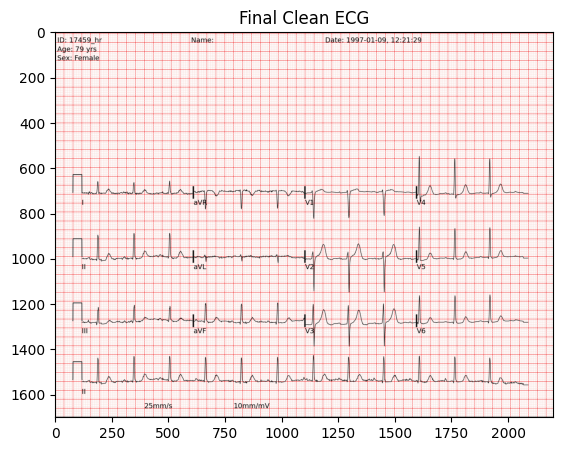

YOLOR 🚀 2026-1-22 torch 2.8.0+cu126 CPU



Fusing layers... 


Model Summary: 314 layers, 36487166 parameters, 6194944 gradients


RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


12 long_leads, Done. (1047.3ms) Inference, (11.9ms) NMS
 The image with the result is saved in: /kaggle/working/exp/preprocessed_merged.png
Done. (1.311s)
Processing: 2352854581
Processing: /kaggle/input/physionet-ecg-image-digitization/test/2352854581.png
1. Cropping to paper...
2. Correcting lighting...
   [Stats] Glare: 0.3720 | Shadow: 0.0144 | Contrast: 46.14
   >> Decision: Glare detected. Applying Glare Fix.


YOLOR 🚀 2026-1-22 torch 2.8.0+cu126 CPU



Saved to: /kaggle/working/preprocessed_merged.png
Fusing layers... 


Model Summary: 314 layers, 36487166 parameters, 6194944 gradients


RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse
13 long_leads, Done. (870.3ms) Inference, (1.0ms) NMS
 The image with the result is saved in: /kaggle/working/exp/preprocessed_merged.png
Done. (1.106s)


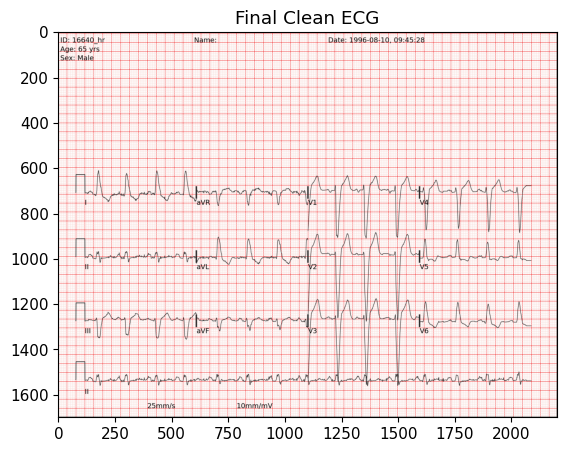

In [13]:
df = pd.read_csv("/kaggle/input/physionet-ecg-image-digitization/test.csv")
submission = run_all(df)
submission.to_csv("submission.csv", index=False)
submission.to_parquet("submission.parquet", index=False)